  # Perkenalan

Notebook ini dibuat sebagai salah satu portfolio Data Analysis Ghaffar Farros, untuk melakukan penerapan rangkaian proses data analisis untuk mengetahui berbagai insight dari dataset yang dipilih berdasarkan metode, metrik, menarik kesimpulan dan memberikan rekomendasi. Hasil akhir nantinya akan divisualisasikan dengan Tableau Public secara interaktif agar mudah dipahami.

# Identifikasi Masalah

## Latar Belakang
Evaluasi terhadap hasil dari berbagai online campaign yang telah dijalankan sebelumnya perlu terus dilakukan untuk meningkatkan efektivitas dan efisiensinya. Tujuan utama dari evaluasi ini adalah untuk menggali wawasan yang dapat diambil dari data yang ada. Insight yang diperoleh nantinya akan menjadi dasar dalam pengambilan keputusan strategis untuk arah dan perbaikan kampanye online di masa mendatang, dengan harapan dapat mencapai target profit yang diinginkan dalam beberapa bulan ke depan. Evaluasi ini akan difokuskan pada upaya peningkatan nilai-nilai metrik yang digunakan untuk menilai keberhasilan setiap kampanye, sehingga hasil yang diperoleh dapat lebih optimal dan mengalami perkembangan yang berkelanjutan.

## Problem Statement

Secara spesifik, project ini ditujukan untuk meningkatkan efektivitas dan efisiensi campaign, dengan meningkatkan jumlah Click-Through Rate dan Conversion Rate. Untuk mengukur keberhasilan project, diproyeksikan nantinya dapat meningkatkan persentase masing-masing metrik pada conversion funnel. Dengan optimasi anggaran dan penentuan saluran promosi yang tepat, project memiliki tujuan yang achievable dengan rentang waktu yang ada. Tujuan ini penting mengingat peningkatan jumlah klik merupakan salah satu faktor penting pada Conversion Funnel, sehingga akan berdampak pada pendapatan. Ketika jumlah klik dan Conversion Rate meningkat, hal ini dapat mendukung pencapaian target perusahaan. Selain itu, evaluasi juga dilakukan secara berkala untuk memastikan progress dan melakukan penyesuaian yang diperlukan. Dengan rentang waktu 3 bulan yang diiringi dengan evalusasi secara berkala, project ini diharapkan menunjukkan hasil yang signifikan.

# Import Library

In [4]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Data Extract

In [5]:
# Download data dari kaggle dengan menggunakan kaggle API
!kaggle datasets download sinderpreet/analyze-the-marketing-spending --unzip


  0%|          | 0.00/7.44k [00:00<?, ?B/s]
100%|██████████| 7.44k/7.44k [00:00<00:00, 801kB/s]



Dataset URL: https://www.kaggle.com/datasets/sinderpreet/analyze-the-marketing-spending
License(s): CC0-1.0



In [6]:
# Read CSV dengan pandas
DF = pd.read_csv('Marketing.csv')
DF

,id,c_date,campaign_name,category,campaign_id,impressions,mark_spent,clicks,leads,orders,revenue
0,1,2021-02-01,facebook_tier1,social,349043,148263,7307.37,1210,13,1,4981.0
1,2,2021-02-01,facebOOK_tier2,social,348934,220688,16300.20,1640,48,3,14962.0
2,3,2021-02-01,google_hot,search,89459845,22850,5221.60,457,9,1,7981.0
3,4,2021-02-01,google_wide,search,127823,147038,6037.00,1196,24,1,2114.0
4,5,2021-02-01,youtube_blogger,influencer,10934,225800,29962.20,2258,49,10,84490.0
...,...,...,...,...,...,...,...,...,...,...,...
303,304,2021-02-28,instagram_tier2,social,983498,775780,760.75,1024,4,0,0.0
304,305,2021-02-28,facebook_retargeting,social,4387490,1933,224.81,58,0,0,0.0
305,306,2021-02-28,facebook_lal,social,544756,25840,6844.80,248,5,1,1491.0
306,307,2021-02-28,instagram_blogger,influencer,374754,94058,4845.65,594,12,1,5008.0


metadata: 
| Kolom  | Deskripsi |
|--------------|------------|
| **id**            | Setiap campaign yang bersifat unik di setiap row. |
| **c_date**        | Campaign date, tanggal campaign dijalankan. |
| **campaign_name** | Nama campaign yang dijalankan sesuai platformnya. |
| **category**      | Kategori campaign yang dijalankan. |
| **campaign_id**   | Nama ID campaign. |
| **impressions**   | Jumlah tayangan iklan yang dilihat audiens. |
| **mark_spent**    | Biaya yang dikeluarkan untuk campaign. |
| **clicks**        | Jumlah campaign yang tayang dan diklik oleh audiens. |
| **leads**         | Audiens yang berpotensi menjadi pelanggan dan memiliki ketertarikan. |
| **orders**        | Jumlah pesanan yang dilakukan dari iklan. |
| **revenue**       | Penghasilan yang diperoleh. |

Dataframe yang digunakan untuk project ini diambil dari kaggle dengan menggunakan kaggle api. Pada dataframe ini terdapat 308 baris data yang diperoleh dan berisi data mengenai campaign yang didapat selama 1 bulan pada Februari 2021. Dataframe ini mengandung informasi metrik yang terdapat pada conversion funnel, yang secara berurutan yaiut: `Impressions, clicks, leads, orders`

# Data Cleaning

## Missing Value & Duplicated

In [ ]:
DF.info()                                                         # cek summary dan info seputar dataframe
print('----------------------------------------------------------------------')
print("Data dengan missing value sebanyak :",DF.isna().sum())     # cek data kosong
print('----------------------------------------------------------------------')
print("Row dengan duplikasi sebanyak :", DF.duplicated().sum())   # cek duplikasi

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             308 non-null    int64  
 1   c_date         308 non-null    object 
 2   campaign_name  308 non-null    object 
 3   category       308 non-null    object 
 4   campaign_id    308 non-null    int64  
 5   impressions    308 non-null    int64  
 6   mark_spent     308 non-null    float64
 7   clicks         308 non-null    int64  
 8   leads          308 non-null    int64  
 9   orders         308 non-null    int64  
 10  revenue        308 non-null    float64
dtypes: float64(2), int64(6), object(3)
memory usage: 26.6+ KB
----------------------------------------------------------------------
Data dengan missing value sebanyak : id               0
c_date           0
campaign_name    0
category         0
campaign_id      0
impressions      0
mark_spent       0
clicks           0


- Sebagian besar data type sudah sesuai, kecuali pada kolom `c_date` yang seharusnya datetime.
- Tidak terdapat data kosong.
- Tidak terdapat duplikasi.

## Data Type

In [8]:
DF['c_date'] = pd.to_datetime(DF['c_date'])             # Mengubah tipe data kolom c_date menjadi datetime
DF['campaign_name'] = DF['campaign_name'].str.lower()   # Mengubah semua huruf pada campaign_name menjadi huruf kecil

penyesuaian dilakukan dengan mengubah data type kolom `c_date` ke tanggal, dan untuk keseragaman kolom  `campaign_name` dibuat lowercase

# Exploratory Data Analysis

## Central tendency, minimal, dan maksimal metrik

In [9]:
desc = DF.describe().round(2)
desc = desc.drop(columns=['id', 'c_date','campaign_id'])
desc = desc.drop(index='count')
desc

,impressions,mark_spent,clicks,leads,orders,revenue
mean,5.122475e+06,99321.04,9740.00,212.92,26.11,139251.19
min,6.670000e+02,169.75,20.00,0.00,0.00,0.00
25%,1.479568e+05,9465.20,1347.25,20.75,3.00,8580.00
50%,6.028100e+05,36765.15,4349.50,84.00,9.00,38917.00
75%,3.254450e+06,129372.25,13499.25,270.50,29.25,137049.25
max,4.199700e+08,880357.00,61195.00,1678.00,369.00,2812520.00
std,2.631134e+07,144008.01,12157.48,300.46,42.74,276303.11


Revenue mewakili pendapatan dan hasil yang dituju perusahaan, dari hasil diketahui rata-rata (mean) pendapatannya adalah Rp139,251.19. Nilai tengah berada di Rp38,917 dan paling banyak muncul adalah 0 yang juga merupakan nilai minimal dan modus revenue. 

Nilai `median` terpaut yang jauh lebih rendah dari `mean` menunjukkan adanya distribusi revenue yang tidak merata, artinya sebagian besar hari (lebih dari 50%) menghasilkan revenue yang jauh lebih rendah dibandingkan dengan hari yang menghasilkan revenue lebih tinggi. Distribusi data digambarkan juga dengan std yang tiap metriknya menunjukkan angka yang besar, std menggambarkan sebaran value dari rata-rata, std yang besar menandakan data menyebar jauh dari rata-rata dan sebaliknya.

## Persentase Campaign

In [30]:
uniq = DF.drop_duplicates(subset=['category', 'campaign_name'])
uniq = uniq[['category', 'campaign_name']].sort_values(by='category').reset_index(drop=True)
uniq

,category,campaign_name
0,influencer,youtube_blogger
1,influencer,instagram_blogger
2,media,banner_partner
3,search,google_hot
4,search,google_wide
5,social,facebook_tier1
6,social,facebook_tier2
7,social,instagram_tier1
8,social,instagram_tier2
9,social,facebook_retargeting


Diatas adalah tabel campaign apa saja yang ada dan termasuk dalam kategori apa, dapat diamati pada kategori influencer misalnya ada campaign youtube blogger dan instagram blogger, dan seterusnya.

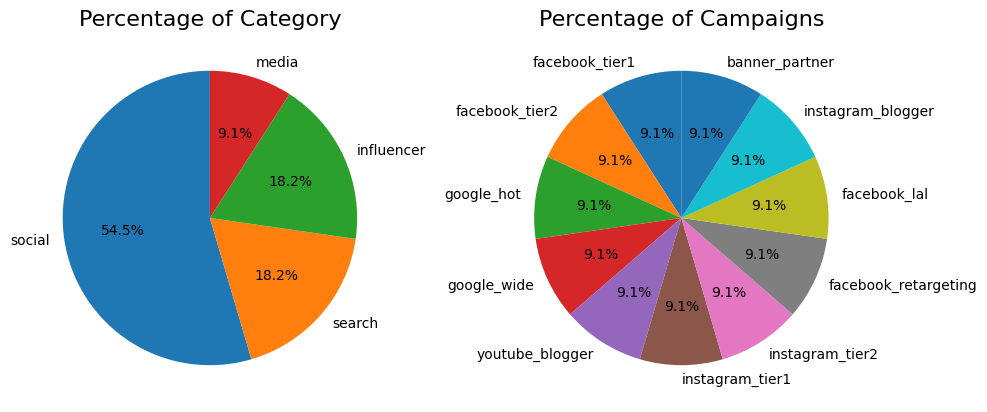

In [10]:
# Proporsi campaign berjalan
category_counts = DF['category'].value_counts()
campaign_counts = DF['campaign_name'].value_counts()

plt.figure(figsize=(10,5))

# Category
plt.subplot(1, 2, 1)
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Percentage of Category', fontsize=16)

# Campaign
plt.subplot(1, 2, 2)
plt.pie(campaign_counts, labels=campaign_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Percentage of Campaigns', fontsize=16)

plt.tight_layout()
plt.show()


Chart diatas menunjukkan persentase promosi yang sedang berlangsung berdasarkan kategori dan jenis campaign-nya. Kategori social media paling besar sebesar 54,5%, dan untuk masing-masing nama campaign proporsinya dibagi rata. Dengan visualisasi ini, dapat diketahui gambaran kategori dan campaign yang sedang berjalan.

## Tren Impression dan Click

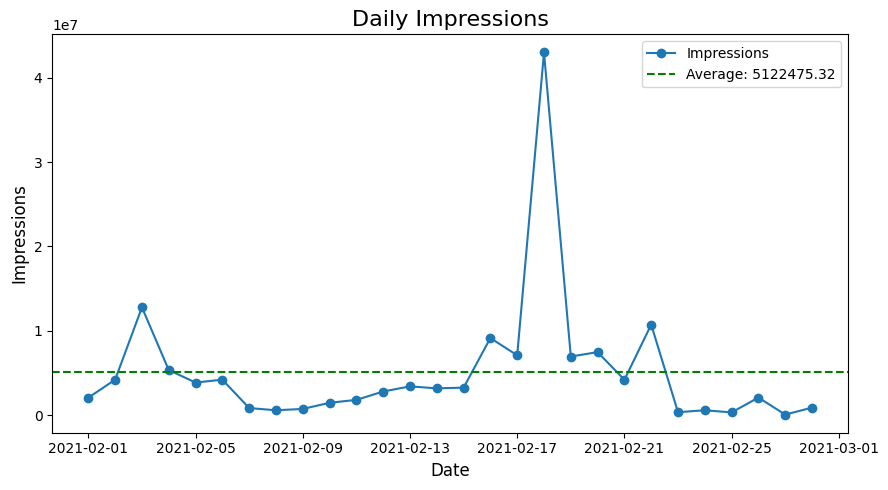

In [11]:
# Data prepare
DT = DF.groupby("c_date")[["impressions", "clicks"]].mean().reset_index()
DT = DT.sort_values('c_date')
avg_imp = DT['impressions'].mean()

# Chart
plt.figure(figsize=(9,5))
plt.plot(DT['c_date'], DT['impressions'], marker='o', label='Impressions')

plt.axhline(y=avg_imp, color='green', linestyle='--', label=f'Average: {avg_imp:.2f}')
plt.title('Daily Impressions', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Impressions', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()


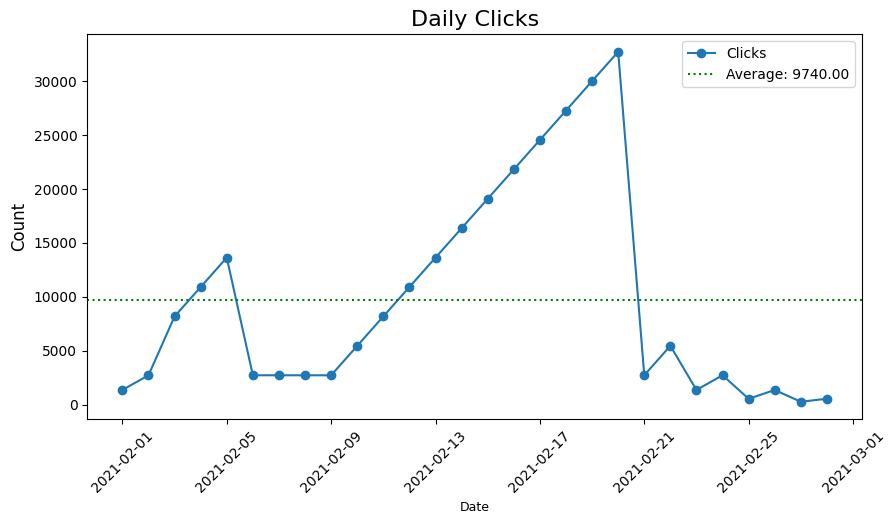

In [12]:
# Data prepare
avg_click = DT['clicks'].mean()

# Chart
plt.figure(figsize=(10,5))
plt.plot(DT['c_date'], DT['clicks'], marker='o', label='Clicks')

plt.axhline(y=avg_click, color='green', linestyle=':', label=f'Average: {avg_click:.2f}')
plt.title('Daily Clicks', fontsize=16)
plt.xlabel('Date', fontsize=9)
plt.ylabel('Count', fontsize=12)
plt.legend()

plt.xticks(rotation=45)
plt.show()

Impressions merupakan metrik yang mengukur jumlah tayangan pada konten yang diiklankan, hal tersebut merupakan pintu pertama dalam sebuah funnel. Diatas nampak line chart total impressions sesuai time frame-nya. Terlihat pada 18 Februari 2021 menunjukkan data impressions yang paling tinggi dibanding lainnya. Clicks mengukur seberapa banyak iklan tersebut dibuka oleh viewers, dan hasil klik paling tinggi berada pada tanggal 20.

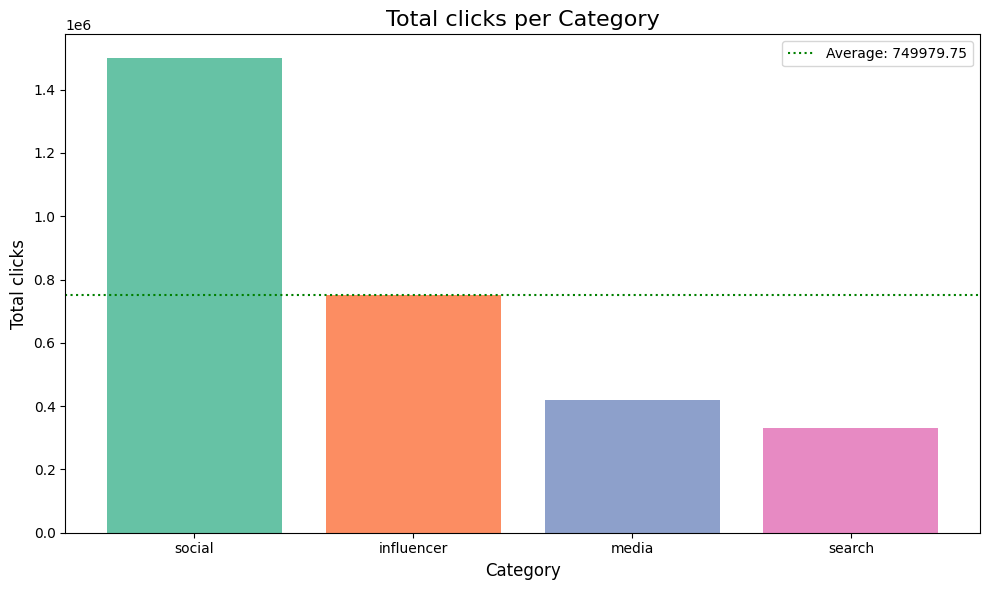

In [13]:
# Data preparation
df_click = DF.groupby('category')['clicks'].sum()
df_click = df_click.sort_values(ascending=False)
avg_r = df_click.mean()

# Pallette
categories = df_click.index
color_palette = sns.color_palette("Set2", n_colors=len(categories))
category_colors = {category: color_palette[i] for i, category in enumerate(categories)}

# Chart
plt.figure(figsize=(10, 6))
bars = plt.bar(df_click.index, df_click.values, color=[category_colors[category] for category in df_click.index])
plt.axhline(y=avg_r, color='green', linestyle=':', label=f'Average: {avg_r:.2f}')
plt.title('Total clicks per Category', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total clicks', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()


Berdasarkan kategorinya, Click terbanyak ditunjukkan oleh social, influencer, media, dan search engine

In [14]:
top_clicks = DF.groupby(['c_date', 'category'])['clicks'].sum().reset_index()
top_clicks = top_clicks.sort_values(by='clicks', ascending=False)

# Ambil top 10 hari dengan klik terbanyak
top_10_days = top_clicks.head(10)
top_10 = top_10_days.sort_values(by='c_date', ascending=False)
top_10

,c_date,category,clicks
79,2021-02-20,social,179972
76,2021-02-20,influencer,89987
75,2021-02-19,social,165019
72,2021-02-19,influencer,82509
71,2021-02-18,social,149985
67,2021-02-17,social,135016
63,2021-02-16,social,119989
59,2021-02-15,social,105006
55,2021-02-14,social,89997
51,2021-02-13,social,75006


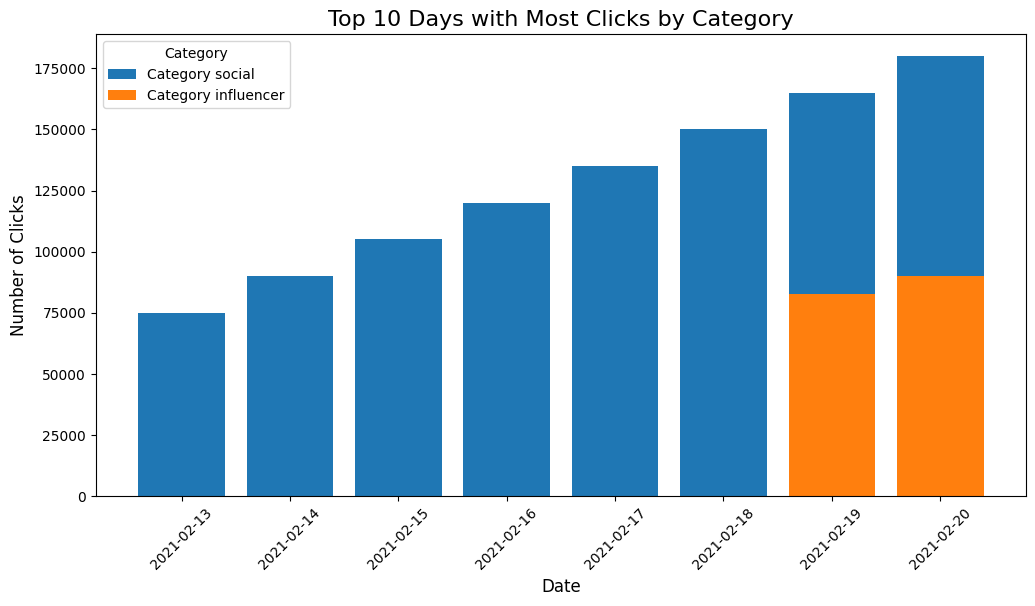

In [15]:
# Visualisasi
plt.figure(figsize=(12, 6))

for category in top_10['category'].unique():
    category_data = top_10[top_10['category'] == category]
    plt.bar(category_data['c_date'], category_data['clicks'], label=f'Category {category}')

plt.title('Top 10 Days with Most Clicks by Category', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Clicks', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Category')

plt.show()

`- Dominasi Kategori "Social":`   
Kategori "social" mendominasi daftar top 10 clicks dengan jumlah yang jauh lebih tinggi dibandingkan kategori lainnya, menunjukkan bahwa kampanye berbasis media sosial sangat efektif dalam menarik klik.

`- Puncak Clicks:  `  
Pada tanggal 9 dan 20 Februari 2021, dua kategori "social" dan "influencer" mencatatkan jumlah klik tertinggi, menandakan bahwa event atau aktivitas yang sangat menarik pada tanggal tersebut, seperti influencer yang berpengaruh, konten yang efektif, peluncuran produk, atau promosi besar. "Viral" menjadi asumsi yang cocok menggambarkan situasi ini mengingat tren bertahap naik sejak tanggal 9 hingga 20.

`- Tren Peningkatan: `  
Terdapat tren peningkatan klik pada kategori "social" mulai dari 9-20 Februari. Peningkatan ini bisa menunjukkan bahwa audiens semakin terlibat atau tertarik dengan kampanye yang berjalan, atau konten yang sedang viral. Kemudian ada penurunan klik yang cukup signifikan dari 20-21 Februari. Ini bisa menunjukkan bahwa efektivitas kampanye cenderung berfluktuasi, dan analisis lebih lanjut diperlukan untuk mengetahui faktor yang mempengaruhi hal ini (misalnya, konten, atau audiens yang terlibat).

`- Peran Influencer: `  
Meskipun kategori "social" lebih dominan, kategori "influencer" tetap menunjukkan angka yang signifikan, terutama pada tanggal 20 Februari. Hal ini mengindikasikan bahwa kolaborasi dengan influencer yang tepat dapat memberikan dampak positif terhadap tingkat interaksi. Kolaborasi dengan influencer pada waktu yang tepat bisa menjadi strategi tambahan untuk meningkatkan klik lebih lanjut.

`- Peluang Fokus pada Kampanye Social Media: `  
Berdasarkan dominasi kategori "social", mungkin lebih baik untuk memfokuskan anggaran dan sumber daya kampanye lebih banyak pada media sosial untuk memaksimalkan jumlah klik dan keterlibatan.

`- Potensi Hari Spesial atau Event: `   
Mengingat tingginya klik pada beberapa tanggal tertentu (terutama 20 Februari), penting untuk menggali lebih dalam apakah ini berkaitan dengan hari spesial, promosi tertentu, atau event yang menarik perhatian audiens. Strategi kampanye dapat dipertimbangkan berdasarkan hal ini.


---


**Visualisasi diatas menunjukkan hasil dari impression dan clicks, namun apakah click yang banyak berarti efisien dalam penggunaan anggaran? Apakah click yang banyak ternyata menggunakan banyak pengeluaran hingga defisit? Selanjutnya akan dibahas dengan rasio antara pendapatan dan pengeluaran.**

## Revenue, Cost, dan Ratio

### Revenue

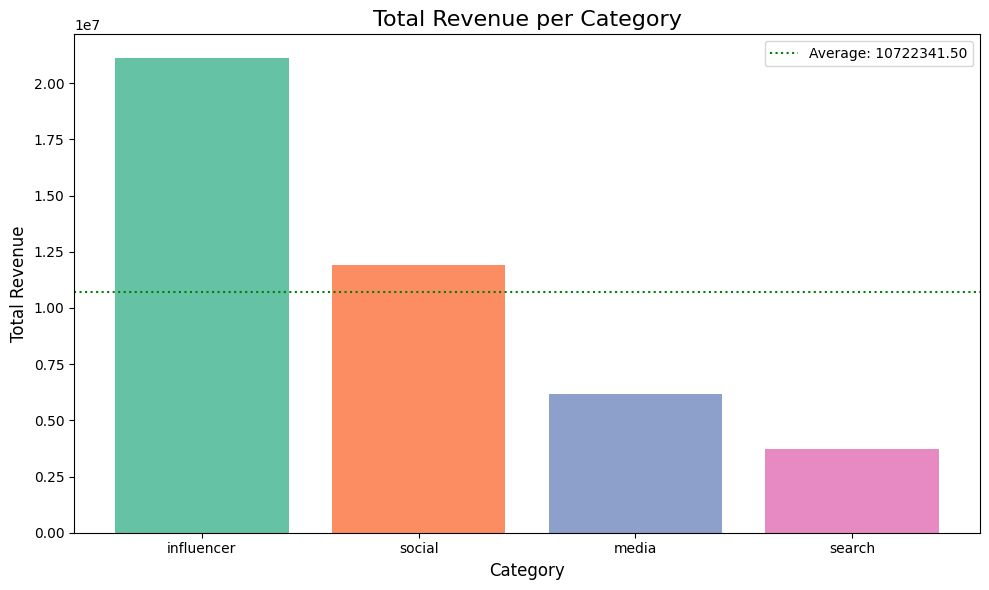

In [17]:
# Data preparation
DR = DF.groupby('category')['revenue'].sum()
DR = DR.sort_values(ascending=False)
avg_r = DR.mean() 

# Pallette
categories = DR.index
color_palette = sns.color_palette("Set2", n_colors=len(categories))
category_colors = {category: color_palette[i] for i, category in enumerate(categories)}

# Chart
plt.figure(figsize=(10, 6))
bars = plt.bar(DR.index, DR.values, color=[category_colors[category] for category in DR.index])
plt.axhline(y=avg_r, color='green', linestyle=':', label=f'Average: {avg_r:.2f}')
plt.title('Total Revenue per Category', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

Pada visualisasi sebelumnya, Click terbanyak dimiliki oleh `social, influencer, media, dan search engine`. Maka pertanyaan berikutnya adalah apakah orang yang melakukan klik pasti melakukan pembelian dan berpengaruh pada revenue? 

Visualisasi diatas menunjukkan pendapatan yang paling besar adalah ketika menggunakan jasa influencer, dan yang paling rendah yaitu ads dengan search engine. Garis putus-putus menunjukkan rata-rata dari keseluruhan revenue, kedua kategori yang termasuk diatas rata-rata adalah influencer (instagram dan youtube blogger), dan social media (instagram dan facebook). 

Maka dapat disimpulkan pada penjualan bulan februari untuk `meningkatkan klik dan mengenalkan brand, kategori social media adalah yang paling cocok`. Sementara `influencer dapat mendorong lebih banyak penjualan` produk sehingga berdampak pada revenue.

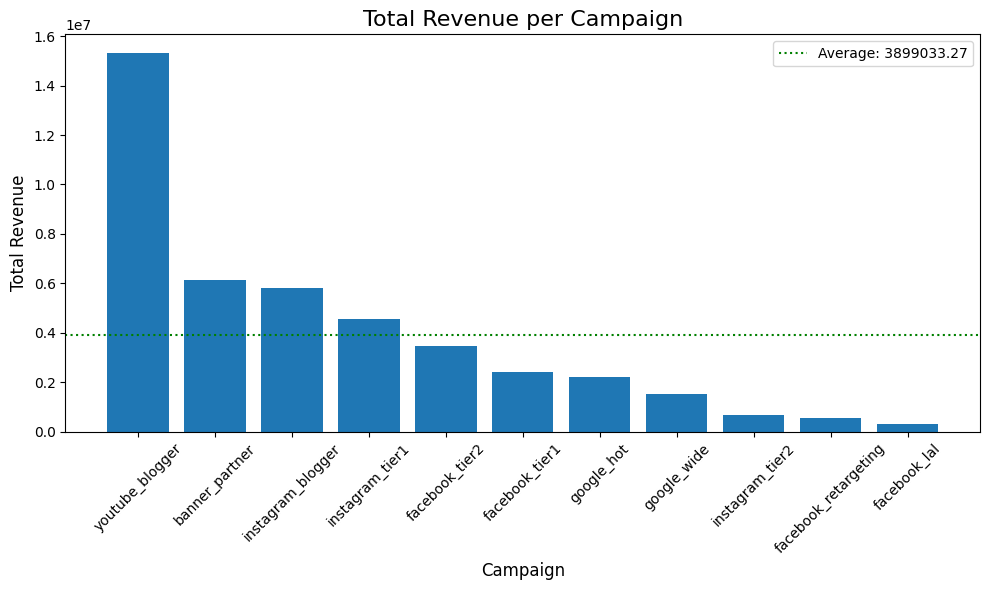

In [18]:
# Data preparation
DCN = DF.groupby('campaign_name')[['revenue']].sum()
DCN = DCN.sort_values(by='revenue', ascending=False)
avg_r = DCN['revenue'].mean()

# Chart
plt.figure(figsize=(10, 6))
plt.bar(DCN.index, DCN['revenue'])

plt.axhline(y=avg_r, color='green', linestyle=':', label=f'Average: {avg_r:.2f}')
plt.title('Total Revenue per Campaign', fontsize=16)
plt.xlabel('Campaign', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()


Bar chart diatas merupakan breakdown campaign per kategorinya. Sebelumnya diketahui per kategori, sumbangan revenue terbesar adalah dari `Influencer, Social, Media, dan yang terakhir Search engine`. Namun apakah ada salah satu sub kategori (campaign) yang mendominasi sehingga mendongkrak revenue kategorinnya? maka digambarkan pada visuaslisasi diatas.

- Kategori Influencer, baik youtube maupun instagram blogger memiliki kontribusi yang sangat baik dan diatas rata-rata keseluruhan. Artinya promosi yang dilakukan dengan bantuan influencer memiliki kontribusi yang nyata dan berdampak pada revenue. 
- Kategori Social, angka revenue yang cukup baik ditunjukkan oleh campaign `instagram tier 1, facebook tier 2 dan facebook tier 1`. Sementara untuk campaign dengan revenue yang rendah dengan jarak terpaut jauh yaitu instagram tier 2, facebook retargeteing dan facebook lal. Social media memiliki campaign yang paling banyak, maka dapat dipertimbangkan apakah marketing perlu melanjutkan beberapa campaign saja dengan memangkas lainnya dan meningkatkan budget.

### Cost

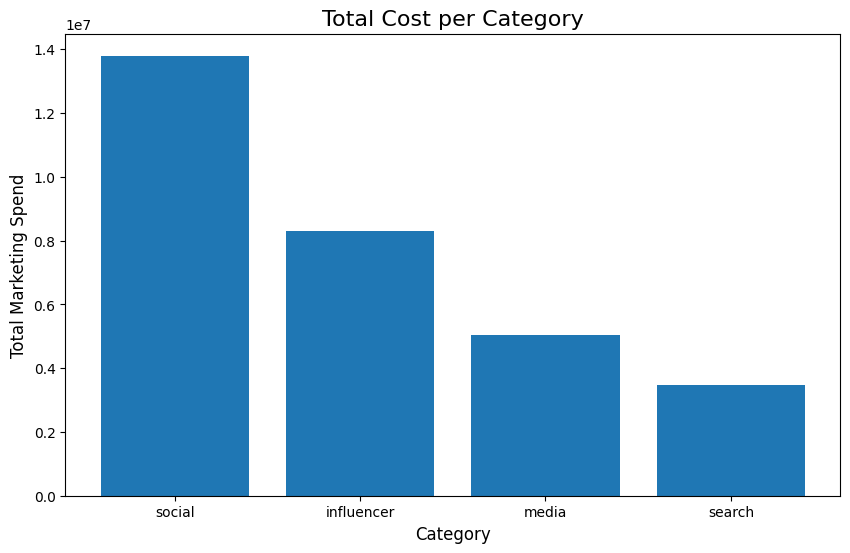

In [20]:
# Data prepare
DR = DF.groupby("category")[["mark_spent"]].sum().reset_index()
DR = DR.sort_values('mark_spent', ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(DR['category'], DR['mark_spent'])
plt.title('Total Cost per Category', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Marketing Spend', fontsize=12)

plt.show()

Bar chart menunjukkan iklan pada platform social media memakan biaya yang paling tinggi, disusul oleh influencer, media, lalu kategori yang paling kecil biayanya yaitu search engine.

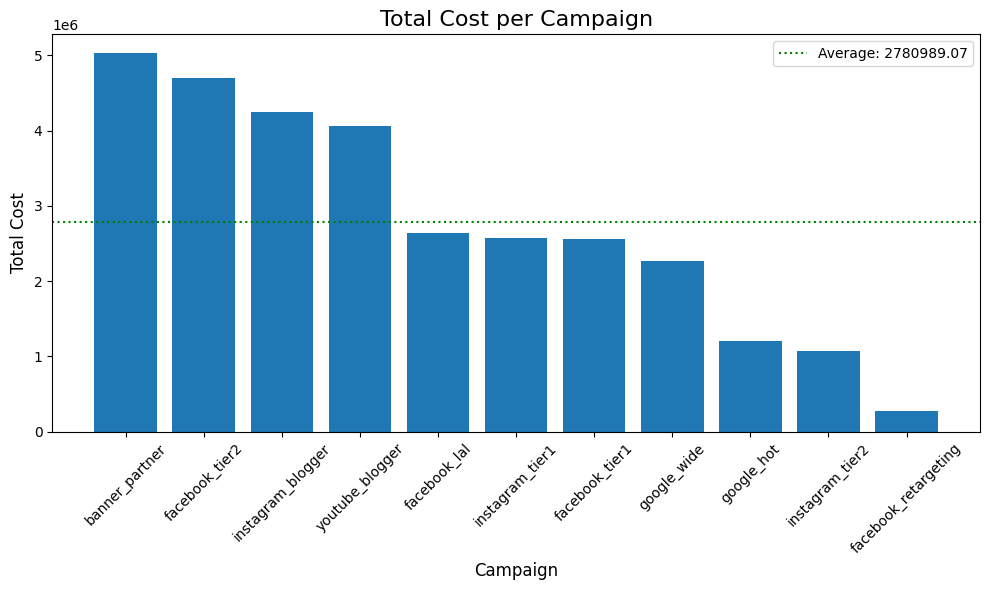

In [33]:
# Data preparation
DS = DF.groupby('campaign_name')[['mark_spent']].sum()
DS = DS.sort_values(by='mark_spent', ascending=False)
avg_r = DS['mark_spent'].mean()

# Chart
plt.figure(figsize=(10, 6))
bars = plt.bar(DS.index, DS['mark_spent'])

plt.axhline(y=avg_r, color='green', linestyle=':', label=f'Average: {avg_r:.2f}')
plt.title('Total Cost per Campaign', fontsize=16)
plt.xlabel('Campaign', fontsize=12)
plt.ylabel('Total Cost', fontsize=12)
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

Cost paling mahal ada pada campaign banner partner, fb tier 2, dan blogger. 2 dari 4 yang berada diatas rata-rata berada pada kategori influencer.

Dari gambaran revenue yang diterima diketahui pemasukan, dari gambaran cost diketahui pengeluaran. Maka apakah sebanding pengeluaran yang digunakan dengan pemasukan yang dihasilkan? Maka perlu dicek lebih lanjut dengan rasio.

### Rasio

#### Cost per Lead

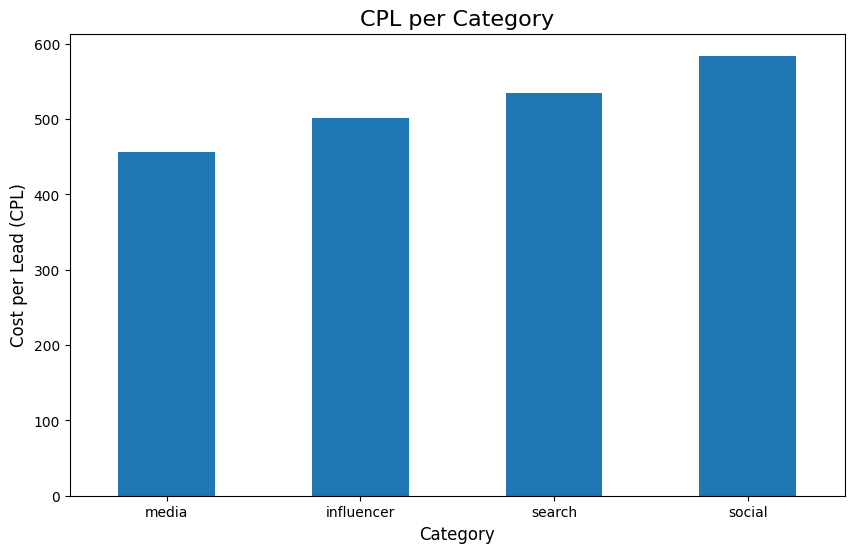

In [22]:
# Data prepare
DF['CPL'] = DF['mark_spent'] / DF['leads']
DF['CPL'] = DF['CPL'].replace([np.inf, -np.inf], np.nan)  # jika ada lead 0 maka akan menjadi infinite, maka diubah menjadi NaN

cpl_per_category = DF.groupby('category')['CPL'].mean()
cpl_per_category = cpl_per_category.sort_values()

# Chart
plt.figure(figsize=(10, 6))
cpl_per_category.plot(kind='bar')
plt.title('CPL per Category', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.xticks(rotation=0)
plt.ylabel('Cost per Lead (CPL)', fontsize=12)

plt.show()

Cost per Lead menunjukkan berapa cost yang dibutuhkan untuk menghasilkan 1 lead. `Semakin kecil angka CPL, menunjukkan semakin kecil cost yang dibutuhkan untuk menghasilkan lead`. Dari visualisasi diatas menunjukkan campaign yang paling efisien dalam menghasilkan lead adalah Media, Influencer, Search Engine, lalu Social Media. Ini merupakan gambaran yang sifatnya agregasi, artinya bisa jadi salah satu campaign berpengaruh cukup besar saat penentuan CPL. Maka perlu ditelusuri lagi hingga per jenis campaign untuk mengetahui campaign mana, dalam kategori mana, yang lebih efisien.

<Figure size 900x600 with 0 Axes>

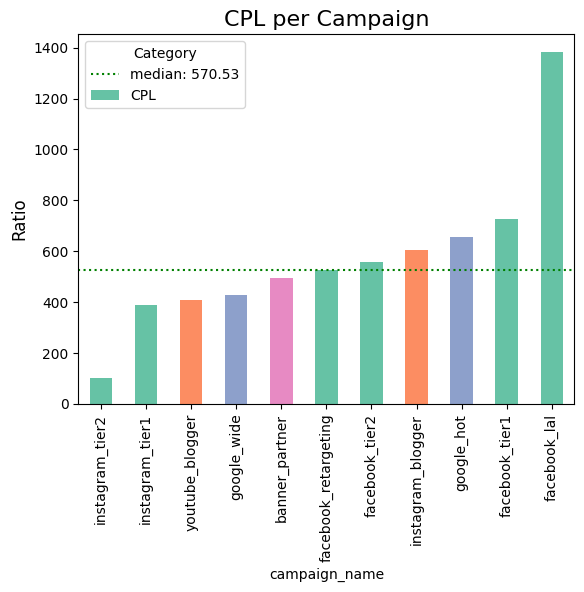

In [36]:
DF_grouped = DF.groupby('campaign_name').agg({
    'mark_spent': 'sum',
    'leads': 'sum',
    'category': 'first'  # Pilih kategori pertama dalam setiap grup
}).reset_index()
DF_grouped['CPL'] = DF_grouped['mark_spent'] / DF_grouped['leads']
DF_grouped = DF_grouped.sort_values(by='CPL')

# Chart
plt.figure(figsize=(9, 6))

# Mengambil kategori unik
categories = DF_grouped['category'].unique()

# Membuat palet warna berdasarkan kategori
color_palette = sns.color_palette("Set2", n_colors=len(categories))
category_colors = {category: color_palette[i] for i, category in enumerate(categories)}

# Membuat bar plot dengan warna sesuai kategori
DF_grouped.plot(kind='bar', x='campaign_name', y='CPL', color=[category_colors[category] for category in DF_grouped['category']])

# Menambahkan judul dan label
plt.title('CPL per Campaign', fontsize=16)
plt.axhline(y=DF_grouped['CPL'].median(), color='green', linestyle=':', label=f'median: {DF_grouped["CPL"].mean():.2f}')
plt.xticks(rotation=90)
plt.ylabel('Ratio', fontsize=12)
plt.legend(title='Category')

# Menampilkan chart
plt.show()

Cost per lead menggambarkan seberapa banyak biaya yang dikeluarkan untuk mendapatkan satu lead (prospek atau calon pelanggan). Secara umum, nilai CPL yang lebih rendah dianggap lebih baik, karena menunjukkan bahwa kita menghabiskan lebih sedikit uang untuk mendapatkan satu lead.

Garis putus-putus menandakan median yang menjadi nilai tengah sebagai acuan data. Facebook lal merupakan campaign yang paling mahal costnya untuk menghasilkan lead, diikuti oleh fb tier 1 dan google hot sebagai 3 termahal penggunaan cost untuk menghasilkan lead. Hal ini dapat menjadi pertimbangan kelak, saluran promosi apa yang tepat untuk menghasilkan lead dengan efisien.

#### Cost to Revenue

In [ ]:
total_revenue = DF['revenue'].sum()
total_spent = DF['mark_spent'].sum()

Profit  = total_revenue - total_spent
rasio = total_spent / total_revenue

# Menampilkan hasil
print("Total Revenue: ", total_revenue)
print("Total Spent: ", total_spent)
print("Profit : ", Profit )
print("Total Rasio Spent to Revenue: ", rasio)

grouped_df = DF.groupby('campaign_name').agg(
    total_mark_spent=('mark_spent', 'sum'),
    total_revenue=('revenue', 'sum')
).reset_index()

grouped_df['Spent per Revenue'] = grouped_df['total_mark_spent'] / grouped_df['total_revenue']
grouped_df = grouped_df.sort_values('Spent per Revenue').reset_index(drop=True)

a = grouped_df['total_mark_spent'].sum()
b = grouped_df['total_revenue'].sum()
grouped_df

Total Revenue:  42889366.0
Total Spent:  30590879.82
Profit :  12298486.18
Total Rasio Spent to Revenue:  0.7132509214521847


,campaign_name,total_mark_spent,total_revenue,Spent per Revenue
0,youtube_blogger,4057936.51,15311433.0,0.265027
1,facebook_retargeting,266466.22,536919.0,0.496288
2,google_hot,1199998.76,2205747.0,0.544033
3,instagram_tier1,2565277.25,4544124.0,0.564526
4,instagram_blogger,4247367.57,5808454.0,0.731239
5,banner_partner,5026674.76,6152960.0,0.816952
6,facebook_tier1,2564793.48,2396412.0,1.070264
7,facebook_tier2,4693870.97,3463306.0,1.355315
8,google_wide,2260401.31,1499318.0,1.507620
9,instagram_tier2,1066153.75,670460.0,1.590182


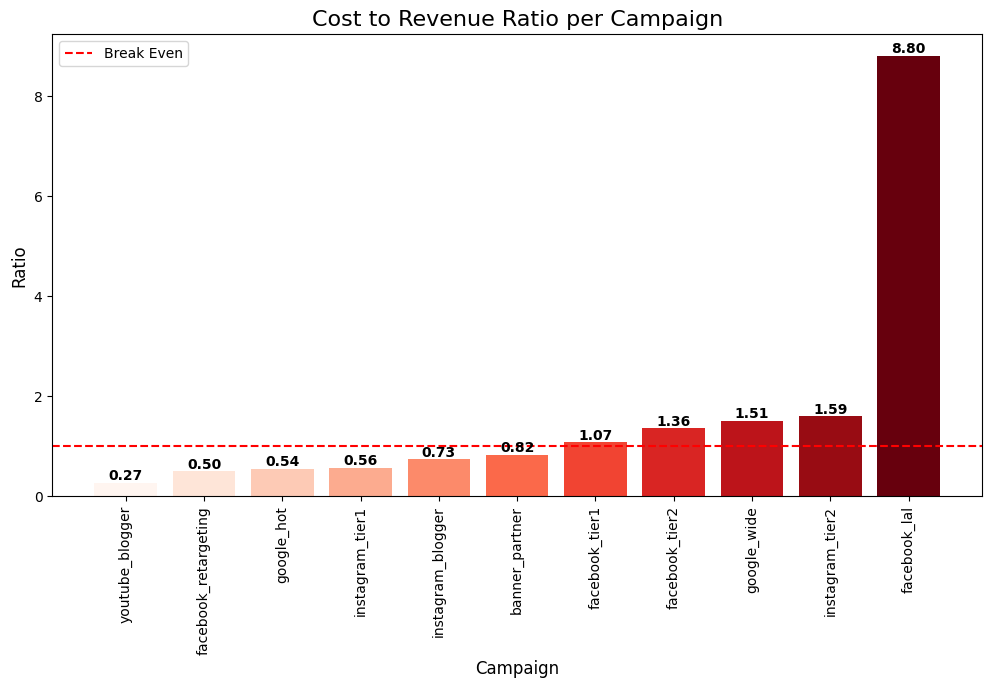

In [ ]:
colors = plt.cm.Reds(np.linspace(0, 1, len(grouped_df)))

# Chart
plt.figure(figsize=(12, 6))
bars = plt.bar(grouped_df['campaign_name'], grouped_df['Spent per Revenue'], color=colors)

# Menambahkan angka di atas setiap batang
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Judul dan label
plt.title('Cost to Revenue Ratio per Campaign', fontsize=16)
plt.xlabel('Campaign', fontsize=12)
plt.ylabel('Ratio', fontsize=12)
plt.xticks(rotation=90)

# Garis horizontal untuk break-even point
plt.axhline(y=1, color='r', linestyle='--')
plt.legend(['Break Even'])

# Menampilkan chart
plt.show()

Nilai Cost to Revenue menunjukkan biaya pemasaran yang dikeluarkan untuk setiap unit pendapatan yang dihasilkan, sehingga semakin kecil nilai Cost to Revenue maka semakin baik dan menunjukkan efisiensi campaign tersebut. Facebook lal memiliki nilai Cost to Revenue yang sangat besar, menandakan setiap $1 pendapatan yang dihasilkan, menggunakan $8 yang dikeluarkan untuk pemasaran. Maka dapat diartikan biaya campaign facebook lal 8x lebih besar daripada keuntungannya. Baiknya cost to revenue berada dibawah 1 (menandakan break even), maka dari visualisasi diatas, fb tier 1, fb tier 2, google wide, ig tier 2 dan facebook lal tidak memenuhi kondisi yang baik. 

## Korelasi biaya dan order

In [26]:
# tes normality dulu untuk kedua variabel diuji
print(f'p-value: {stats.normaltest(DF["mark_spent"]).pvalue}')
print(f'p-value: {stats.normaltest(DF["orders"]).pvalue}')

# Skewness
print(f"Skewness: {DF['mark_spent'].skew()}")
print(f"Skewness: {DF['orders'].skew()}")

# Kurtosis
print(f"Kurtosis: {DF['mark_spent'].kurtosis()}")
print(f"Kurtosis: {DF['orders'].kurtosis()}")


p-value: 2.377796545834737e-34
p-value: 8.310576505686648e-56
Skewness: 2.24123710500904
Skewness: 3.3837251196171843
Kurtosis: 5.50155454580627
Kurtosis: 16.88623130763034


Untuk mengetahui uji apa yang digunakan, maka terlebih dahulu dicek normalitas datanya. 
- Dari hasil normaltest, diketahui bahwa p-value < 0.05 maka data termasuk dalam kategori `tidak normal`.
- Skewness juga digunakan untuk mengetahui simetrikal distribusi. Hasil dari 2 variabel (2.24 dan 3.38) > 1 dan menunjukkan bahwa distribusinya `highly skewed` (sangat miring). Jika digambarkan grafiknya, maka ekor memanjang kekanan
- Nilai > 0 maka masuk kategori `Leptokurtic`, memiliki ekor yang tebal dan puncak yang lebih tinggi dibandingkan dengan distribusi normal. Hal ini menunjukkan bahwa data memiliki lebih banyak outlier.

## Inferensial Statistik
Keseluruhan data ingin digunakan untuk menunjukkan keaslian hasil campaign tanpa ada modifikasi data. Metode yang digunakan adalah `Spearman` karena data tidak normal dan skew, dimana metode ini tidak mengasumsikan distribusi tertentu untuk data dan sesuai untuk variabel yang mungkin tidak memiliki hubungan linier. Uji ini lebih stabil terhadap data yang memiliki banyak outlier atau tingkat skewness tinggi.

**Hipotesis**
- Hipotesis Nol (H₀): Tidak ada hubungan signifikan antara biaya yang dikeluarkan (mark_spent) dan jumlah pesanan (orders). Artinya, perubahan pada biaya yang dikeluarkan tidak memengaruhi jumlah pesanan.
- Hipotesis Alternatif (H₁): Ada hubungan signifikan antara biaya yang dikeluarkan (mark_spent) dan jumlah pesanan (orders). Artinya, perubahan pada biaya yang dikeluarkan memengaruhi jumlah pesanan.

In [27]:
corr_rho, pval_s = stats.spearmanr(DF['mark_spent'], DF['orders'])
print(f"r-correlation: {corr_rho:.2f}, p-value: {pval_s}")

r-correlation: 0.97, p-value: 6.921768534437307e-184


Korelasi Spearman sebesar 0.97 menunjukkan adanya hubungan yang sangat kuat dan positif antara kedua variabel (biaya yang dikeluarkan dan jumlah pesanan). Artinya, semakin tinggi biaya yang dikeluarkan (misalnya untuk iklan), semakin banyak jumlah pesanan yang diperoleh.

P-value yang sangat kecil (lebih kecil dari 0.05) menunjukkan bahwa hubungan yang ditemukan tidak mungkin terjadi secara kebetulan. Dalam hal ini,  hipotesis nol (H₀) dapat ditolak dan hipotesis alternatif (H₁) diterima, sehingga dapat dinyatakan bahwa `ada hubungan yang signifikan antara biaya yang dikeluarkan dan jumlah pesanan`.

# Kesimpulan & Rekomendasi

## Kesimpulan

**Distribusi:**  
Nilai `median` terpaut jauh lebih rendah dari `mean` menunjukkan adanya distribusi revenue yang tidak merata, sebagian besar hari (lebih dari 50%) menghasilkan revenue yang jauh lebih rendah dibandingkan dengan hari yang menghasilkan revenue lebih tinggi.

**Running Campaign:**  
Seluruh campaign (11) dijalankan dengan jumlah yang sama, namun kategori social media mendominasi yaitu sebesar 54,5%

**Tren Impressions dan Clicks:**  
- Pada tanggal 9 dan 20 Februari 2021, dua kategori "social" dan "influencer" mencatatkan jumlah Clicks tertinggi
- Kategori "social" mendominasi daftar top 10 Clicks dengan jumlah yang jauh lebih tinggi dibandingkan kategori lainnya
- Kategori "influencer" juga mencatatkan jumlah yang cukup signifikan di top 10 hari dengan klik terbanyak


**Revenue:**  
- Dari 4 Kategori, `Influencer & social` memiliki revenue paling besar. Untuk `Media dan Search` berada dibawah rata-rata
- Dari 11 Campaign,  youtube dan instagram blogger `(influencer)` memiliki kontribusi yang sangat baik dan diatas rata-rata keseluruhan. Promosi yang dilakukan dengan bantuan influencer memiliki kontribusi yang nyata dan berdampak pada revenue. 
- Kategori `Social`, revenue yang baik yaitu `instagram tier 1, facebook tier 2 dan facebook tier 1`. Lainnya jauh dibawah rata2.

**Cost:**  
- Secara berurutan dari yang terbesar, cost termahal yaitu: Social , Influencer, Media, dan Search
- Cost paling mahal ada pada campaign banner partner, fb tier 2, dan blogger. 2 dari 4 yang berada diatas rata-rata berada pada kategori influencer.

**Ratio:**
- Cost per Lead. Secara keseluruhan tiap kategorinya menunjukkan nilai relatif berdekatan. Setelah di breakdown per campaign, nilai paling buruk ditunjukkan `facebook lal` seccara signifikan. Nilai lain yang diatas rata-rata adalah fb tier 1, google hot, ig blogger, dan fb tier 2. Sementara nilai CPL paling baik ditunjukkan oleh IG tier 2.
- Nilai Cost to Revenue pada kategori influencer, keduanya menunjukkan hasil yang baik (dibawah 1). Sementara facebook lal kembali menunjukkan angka yang tidak baik dimana biaya ayng dikeluarkan 8x lipat lebih besar daripada pemasukannya. Mayoritas rasio ini yang bernilai diatas 1 lainnya berasal dari kategori social media.

**Inferensial Statistik:**  
- Keseluruhan data ingin digunakan untuk menunjukkan keaslian hasil campaign. Koefisien Korelasi Spearman (r): 0,97, yang menunjukkan adanya korelasi yang sangat kuat dan positif antara biaya yang dikeluarkan dan jumlah pesanan.P-Value: Lebih kecil dari 0,05 (5%), yang berarti H0 ditolak dan H1 diterima. Ini menunjukkan bahwa hubungan yang ditemukan antara biaya iklan dan jumlah pesanan adalah signifikan dan bukan kebetulan. 
- Budget iklan berhubungan erat dengan peningkatan jumlah pesanan, memberikan indikasi bahwa alokasi anggaran iklan yang lebih tinggi dapat meningkatkan hasil penjualan.

## Rekomendasi  
- Mempertahankan saluran promosi dengan cost to revenue dibawah 1 (youtube blogger, fb retargeting, google hot, ig tier 1, ig blogger, banner partner)
- Pertimbangkan menghapus facebook lal karena besar dalam anggaran namun tidak berdampak pada metrik yang ada dalam conversion funnel
- Saluran promosi lain yang memiliki CPL baik namun Cost to Revenuenya diatas 1 (dekat dengan break even) dapat di evaluasi
- Gali lebih dalam jasa influencer, konten, dan event mulai tanggal 9-20 disaat impression memuncak.
- Kategori influencer menghasilkan revenue tertinggi, maka bisa pertimbangkan untuk memperluas kolaborasi dengan influencer yang memiliki audiens relevan.
- Kenaikan budget campaign sejalan dengan kenaikan jumlah order, masih bisa dilakukan seiring dengan monitoring berkala.
- Monitoring dan Evaluasi bulanan, lakukan tindakan korektif yang diperlukan untuk memastikan target dapat tercapai sebelum akhir periode.

# Save to CSV

In [28]:
DF.to_csv('Marketing.csv', index=False)